# 11 · PJM Energy Demand — Capstone & Synthesis

## Part 11 — Capstone & Synthesis

Eleven notebooks took the PJM demand series from a raw, DST-corrupted panel to a calibrated day-ahead
forecaster and an unsupervised regime map. This capstone consolidates **the system in numbers**, the
**final forecasting scoreboard**, and the **transferable lessons** of a complete time-series project.

In [1]:
import sys, pathlib, warnings
warnings.filterwarnings("ignore")
ROOT = pathlib.Path.cwd(); ROOT = ROOT if (ROOT / "src").exists() else ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import data, eda
eda.set_style()
pd.set_option("display.width", 130, "display.max_columns", 40)
print("setup ok | numpy", np.__version__, "| pandas", pd.__version__)

from src import forecasting as F
from sklearn.linear_model import LinearRegression
from lightgbm import LGBMRegressor
d = data.clean_primary(); s = d.load_mw
print("PJME demand:", len(s), "hours,", s.index.min().date(), "->", s.index.max().date())

setup ok | numpy 2.1.3 | pandas 2.3.3


PJME demand: 145392 hours, 2002-01-01 -> 2018-08-03


### 1. The system in one picture

The 16-year daily-mean series with its all-time peak marked — heat-wave summers spiking above the
gently declining baseline. A whole grid's life in one line.

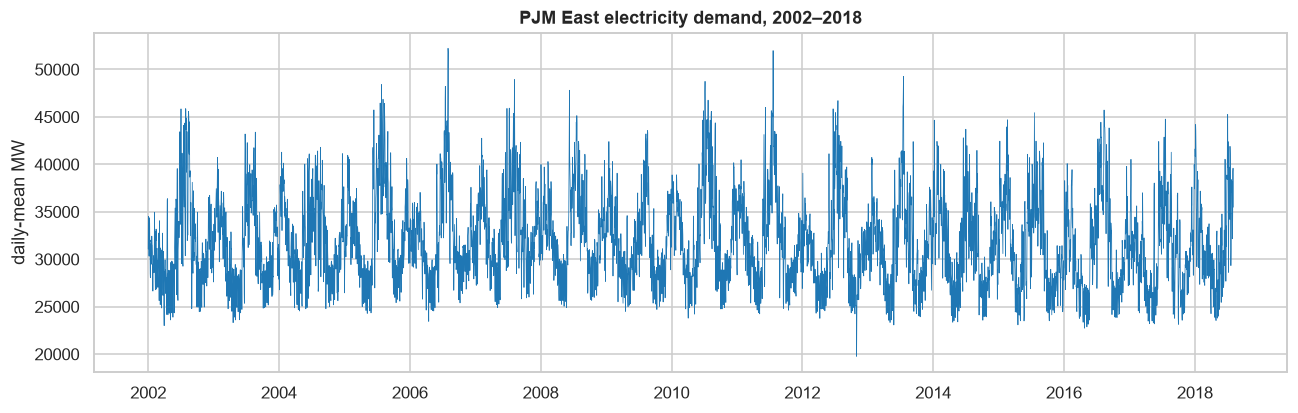

In [2]:
daily = s.resample("D").mean()
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily.values, color="tab:blue", lw=.5)
pk = s.idxmax(); ax.annotate("all-time peak\n%.0f MW\n%s" % (s.max(), pk.date()), xy=(pk, s.max()),
            xytext=(pk - pd.Timedelta(days=900), 50000), arrowprops=dict(arrowstyle="->", color="red"), color="red", fontsize=9)
ax.set_ylabel("daily-mean MW"); ax.set_title("PJM East electricity demand, 2002–2018")
eda.savefig(fig, "p11_overview.png"); plt.show()

### 2. Structural facts (the EDA, distilled)

In [3]:
facts = pd.DataFrame([
    ("span / resolution",      "2002–2018, hourly (145k points)"),
    ("level",                  "mean 32,079 MW, range 14,544–62,009"),
    ("seasonality",            "triple (daily 24h, weekly 168h, BIMODAL annual)"),
    ("daily shape",            "summer single afternoon peak vs winter double peak"),
    ("persistence / memory",   "lag-1 autocorr 0.97; Hurst 0.84 (long-memory)"),
    ("calendar effects",       "weekend -10%, holiday -6%"),
    ("peak/base ratio",        "4.3 (grid sized for a few extreme summer hours)"),
    ("long-run trend",         "-3% over 2003-17 (efficiency > growth)"),
    ("multivariate",           "6 zones, PC1 = 90% common weather factor"),
    ("day-types",              "4 unsupervised load-shape regimes"),
], columns=["property", "finding"])
print(facts.to_string(index=False))

            property                                            finding
   span / resolution                    2002–2018, hourly (145k points)
               level                mean 32,079 MW, range 14,544–62,009
         seasonality    triple (daily 24h, weekly 168h, BIMODAL annual)
         daily shape summer single afternoon peak vs winter double peak
persistence / memory      lag-1 autocorr 0.97; Hurst 0.84 (long-memory)
    calendar effects                          weekend -10%, holiday -6%
     peak/base ratio    4.3 (grid sized for a few extreme summer hours)
      long-run trend             -3% over 2003-17 (efficiency > growth)
        multivariate           6 zones, PC1 = 90% common weather factor
           day-types                  4 unsupervised load-shape regimes


### 3. The final forecasting scoreboard

A like-for-like **24-hour-ahead** comparison on the 2018 hold-out: persistence (same hour yesterday),
deterministic harmonic regression, and the LightGBM with lag/calendar features. The ranking captures
the whole forecasting arc — **persistence is a strong bar, calendar-only is not enough, and ML that
fuses persistence + calendar wins**.

                      MAE      RMSE   MAPE%   WAPE%   MASE
persistence-24h  2530.469  3397.105   7.905   7.962  1.171
harmonic-OLS     3247.252  4167.998  10.150  10.217  1.503
LightGBM-24h     2029.588  2725.405   6.271   6.386  0.940


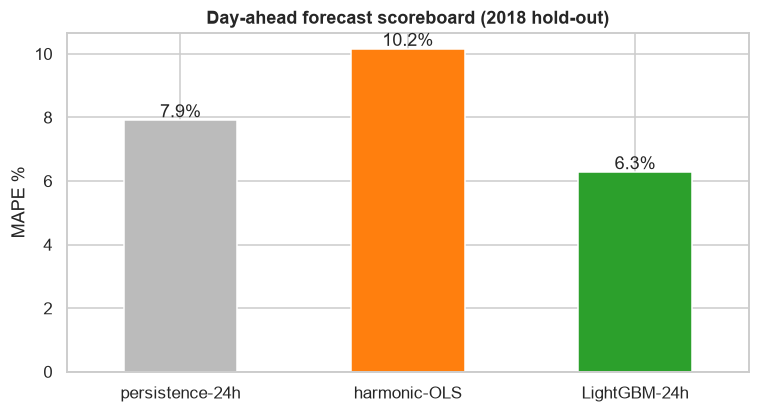

In [4]:
X = F.ml_features(s, d, 24); m = X.dropna().index; tr = m < "2018-01-01"
yte = s.loc[m][~tr]; train_s = s.loc[:yte.index[0]].iloc[:-1]
board = {}
board["persistence-24h"] = s.shift(24).loc[yte.index].values
Xf = F.fourier_features(s.index); Xf["t"] = (s.index - s.index[0]) / pd.Timedelta(hours=1)
lr = LinearRegression().fit(Xf.loc[m][tr], s.loc[m][tr]); board["harmonic-OLS"] = lr.predict(Xf.loc[m][~tr])
board["LightGBM-24h"] = LGBMRegressor(n_estimators=600, learning_rate=0.05, num_leaves=64, verbose=-1, n_jobs=-1).fit(X.loc[m][tr], s.loc[m][tr]).predict(X.loc[m][~tr])
sb = pd.DataFrame({k: F.metrics(yte.values, v, train_s, k) for k, v in board.items()}).T
print(sb.to_string())
fig, ax = plt.subplots(figsize=(8, 4)); sb["MAPE%"].plot.bar(ax=ax, color=["#bbb","tab:orange","tab:green"], rot=0)
ax.set_ylabel("MAPE %"); ax.set_title("Day-ahead forecast scoreboard (2018 hold-out)")
for i, v in enumerate(sb["MAPE%"]): ax.text(i, v+.1, f"{v:.1f}%", ha="center")
eda.savefig(fig, "p11_scoreboard.png"); plt.show()

### 4. The arc of the study

- **0 Cleaning** — assembled an 11-zone panel; fixed the **local-time/DST** duplicate & missing hours.
- **1–2 Advanced EDA** — triple + **bimodal** seasonality, season-dependent daily shapes, ramps,
  summer volatility, declining trend.
- **3 TS foundations** — the ADF/KPSS **seasonality trap**, ACF/PACF, **MSTL** multi-seasonal
  decomposition.
- **4 Spectral** — periodogram peaks; the bimodal cycle showing at **½-year**; **Hurst 0.84**
  long-memory.
- **5 Multivariate** — one **90% common factor** (weather) drives every zone; no lead-lag.
- **6 Anomalies** — calendar-residual scoring rediscovered the **holiday calendar**; **change-points**
  into the efficiency era.
- **7–8 Forecasting** — MSTL beats naive; **LightGBM (lags+calendar) wins day-ahead at ~6% MAPE**.
- **9 Probabilistic** — quantile intervals under-cover; **CQR** restores honest coverage; walk-forward
  stability.
- **10 Profiling** — four unsupervised **day-shape regimes** matching the calendar.

### 5. What transfers — lessons for any time-series project

1. **Clean for the domain first** — local-time/DST, duplicates, and gaps silently corrupt every
   seasonal stat downstream.
2. **Respect multiple seasonality** — single-period tools (plain STL, one Fourier period) miss
   daily×weekly×annual; use **MSTL** and the frequency domain.
3. **Stationarity tests lie under seasonality** — deseasonalise before trusting ADF/KPSS.
4. **Baselines are strong** — seasonal-naive is hard to beat; always report MASE against it.
5. **ML wins by *combining*** persistence + calendar + nonlinearity — and lag features carry most of
   the signal.
6. **A point forecast isn't enough** — quantify uncertainty, and **conformalize** because raw quantiles
   over-cover/under-cover.
7. **Backtest walk-forward** — one split flatters; rolling re-training proves stability.

### The PJM energy-demand study is complete (Parts 0–11).

See **`docs/`** for the beginner-friendly concept glossary and line-by-line code walkthrough.